In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/amakapeace/rai-project/__results__.html
/kaggle/input/notebooks/amakapeace/rai-project/__notebook__.ipynb
/kaggle/input/notebooks/amakapeace/rai-project/__output__.json
/kaggle/input/notebooks/amakapeace/rai-project/custom.css
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-Policy-FSF-TechnicalReport-2025.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-Policy-FSF-v1-2024.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/Google-Report-AIPrinciples-Progress-2023.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/Google-Report-AIResponsibility-2024.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-ModelCard-Gemini2FlashLite-2025.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-TechReport-Imagen3-2024.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-ModelCard-Gemini2.5Flash-2025.pdf
/kaggle/inpu

In [2]:
# Install libraries believe I need for PDF extraction and text processing.
# Kaggle already includes many packages, so we only install what we need.

!pip install pdfplumber spacy --quiet

# Download the spaCy English model used for text processing.
# Safe to run even if it is already installed.

!python -m spacy download en_core_web_sm

# Import libraries for data handling, text processing, and modeling.

import os
import re

import pandas as pd
import numpy as np

import pdfplumber

import spacy

import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt', quiet=True)

import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict

# Load spaCy model and allow large documents

nlp = spacy.load("en_core_web_sm")
nlp.max_length = 2000000

print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 71.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Setup complete.


In [3]:
# Set file paths for input PDFs and output files

# Base folder where my PDFs are stored in Kaggle

PDF_FOLDER = "/kaggle/input/datasets/amakapeace/raiusedpdf/"



COMPANY_FOLDERS = {
    "Anthropic":       "Anthropic",
    "OpenAI":          "OpenAI",
    "GoogleDeepMind":  "GoogleDeepMind",  
    "Microsoft":       "Microsoft",
    "Meta":            "Meta",            
}


# Folder where processed outputs will be saved
OUTPUT_FOLDER = "/kaggle/working"


# Create output directories 

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_FOLDER, "clean_texts"), exist_ok=True)

# Quick check: print all PDF paths so you can verify folder names
print("PDF files found in dataset:")
for root, dirs, files in os.walk(PDF_FOLDER):
    for f in files:
        if f.endswith(".pdf"):
            print(os.path.join(root, f))

PDF files found in dataset:
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-Policy-FSF-TechnicalReport-2025.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-Policy-FSF-v1-2024.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/Google-Report-AIPrinciples-Progress-2023.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/Google-Report-AIResponsibility-2024.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-ModelCard-Gemini2FlashLite-2025.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-TechReport-Imagen3-2024.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/GoogleDeepMind-ModelCard-Gemini2.5Flash-2025.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/Google-Report-AIPrinciples-Progress-2022.pdf
/kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind/Google-Report-AIResponsibility-Feb2025.pdf
/kaggle/input/datasets/amak

In [4]:
# Check folder structure (important for debugging)

for root, dirs, files in os.walk(PDF_FOLDER):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", len(files))
    print("-" * 40)

Folder: /kaggle/input/datasets/amakapeace/raiusedpdf/
Subfolders: ['GoogleDeepMind', 'Meta', 'OpenAI', 'Microsoft', 'Anthropic']
Files: 0
----------------------------------------
Folder: /kaggle/input/datasets/amakapeace/raiusedpdf/GoogleDeepMind
Subfolders: []
Files: 16
----------------------------------------
Folder: /kaggle/input/datasets/amakapeace/raiusedpdf/Meta
Subfolders: []
Files: 9
----------------------------------------
Folder: /kaggle/input/datasets/amakapeace/raiusedpdf/OpenAI
Subfolders: []
Files: 12
----------------------------------------
Folder: /kaggle/input/datasets/amakapeace/raiusedpdf/Microsoft
Subfolders: []
Files: 7
----------------------------------------
Folder: /kaggle/input/datasets/amakapeace/raiusedpdf/Anthropic
Subfolders: []
Files: 14
----------------------------------------


In [5]:
# Step 2: Build the corpus metadata table
#
# I define each document manually to ensure full control over:
# - company
# - year
# - document type
#
# Each row represents one document in the corpus.
# The filename must match exactly with the uploaded PDF file in Kaggle.
#
# The document types reflect the categories I use in my analysis:
# model_card, system_card, policy_governance,
# transparency_report, technical_report,
# safety_report, gov_response, audit_report, assessment   

DOCUMENTS = [
    # Anthropic (14 documents)
    {"filename": "Anthropic-Paper-ConstitutionalAI-2022.pdf",            "company": "Anthropic",      "year": 2022, "doc_type": "technical_report"},
    {"filename": "Anthropic-ModelCard-Claude2-2023.pdf",                 "company": "Anthropic",      "year": 2023, "doc_type": "model_card"},
    {"filename": "Anthropic-Policy-RSP-v1-2023.pdf",                     "company": "Anthropic",      "year": 2023, "doc_type": "policy_governance"},
    {"filename": "Anthropic-ModelCard-Claude3-2024.pdf",                 "company": "Anthropic",      "year": 2024, "doc_type": "model_card"},
    {"filename": "Anthropic-ModelCard-Claude3-Addendum-2024.pdf",        "company": "Anthropic",      "year": 2024, "doc_type": "model_card"},
    {"filename": "Anthropic-ModelCard-Claude3-OctoberAddendum-2024.pdf", "company": "Anthropic",      "year": 2024, "doc_type": "model_card"},
    {"filename": "Anthropic-Policy-RSP-v2-2024.pdf",                     "company": "Anthropic",      "year": 2024, "doc_type": "policy_governance"},
    {"filename": "Anthropic-Policy-VoluntaryCommitments-2024.pdf",       "company": "Anthropic",      "year": 2024, "doc_type": "policy_governance"},
    {"filename": "Anthropic-ModelCard-Claude3.7-2025.pdf",               "company": "Anthropic",      "year": 2025, "doc_type": "model_card"},
    {"filename": "Anthropic-Policy-RSP-v2.2-2025.pdf",                   "company": "Anthropic",      "year": 2025, "doc_type": "policy_governance"},
    {"filename": "Anthropic-Policy-ASL3-DeploymentSafeguards-2025.pdf",  "company": "Anthropic",      "year": 2025, "doc_type": "policy_governance"},
    {"filename": "Anthropic-SystemCard-Claude4-2025.pdf",                "company": "Anthropic",      "year": 2025, "doc_type": "system_card"},
    {"filename": "Anthropic-GovResponse-OSTP-RFI-2025.pdf",              "company": "Anthropic",      "year": 2025, "doc_type": "gov_response"},
    {"filename": "Anthropic-RiskReport-Pilot-2025.pdf",                  "company": "Anthropic",      "year": 2025, "doc_type": "safety_report"},
    
    # OpenAI (12 documents)
    {"filename": "OpenAI-SystemCard-GPT4-2023.pdf",                      "company": "OpenAI",         "year": 2023, "doc_type": "system_card"},
    {"filename": "OpenAI-SystemCard-GPT4V-2023.pdf",                     "company": "OpenAI",         "year": 2023, "doc_type": "system_card"},
    {"filename": "OpenAI-Policy-PreparednessFramework-2023.pdf",         "company": "OpenAI",         "year": 2023, "doc_type": "policy_governance"},
    {"filename": "OpenAI-TechnicalReport-GPT-4-2023.pdf",                "company": "OpenAI",         "year": 2023, "doc_type": "technical_report"},
    {"filename": "OpenAI-SystemCard-GPT4o-2024.pdf",                     "company": "OpenAI",         "year": 2024, "doc_type": "system_card"},
    {"filename": "OpenAI-SystemCard-o1-2024.pdf",                        "company": "OpenAI",         "year": 2024, "doc_type": "system_card"},
    {"filename": "OpenAI-Policy-ExternalRedTeaming-2024.pdf",            "company": "OpenAI",         "year": 2024, "doc_type": "technical_report"},
    {"filename": "OpenAI-SystemCard-Operator-2025.pdf",                  "company": "OpenAI",         "year": 2025, "doc_type": "system_card"},
    {"filename": "OpenAI-SystemCard-GPT4.5-2025.pdf",                    "company": "OpenAI",         "year": 2025, "doc_type": "system_card"},
    {"filename": "OpenAI-SystemCard-o3-o4mini-2025.pdf",                 "company": "OpenAI",         "year": 2025, "doc_type": "system_card"},
    {"filename": "OpenAI-SystemCard-GPT5-2025.pdf",                      "company": "OpenAI",         "year": 2025, "doc_type": "system_card"},
    {"filename": "OpenAI-Policy-VoluntaryCommitments-Paris-2025.pdf",    "company": "OpenAI",         "year": 2025, "doc_type": "policy_governance"},
    

    # Google DeepMind (16 documents)
    {"filename": "Google-Report-AIPrinciples-Progress-2022.pdf",         "company": "GoogleDeepMind", "year": 2022, "doc_type": "transparency_report"},
    {"filename": "Google-Report-AIPrinciples-Progress-2023.pdf",         "company": "GoogleDeepMind", "year": 2023, "doc_type": "transparency_report"},
    {"filename": "GoogleDeepMind-TechReport-Gemini1-2023.pdf",           "company": "GoogleDeepMind", "year": 2023, "doc_type": "technical_report"},
    {"filename": "GoogleDeepMind-TechReport-Gemini1.5-2024.pdf",         "company": "GoogleDeepMind", "year": 2024, "doc_type": "technical_report"},
    {"filename": "Google-Report-AIResponsibility-2024.pdf",              "company": "GoogleDeepMind", "year": 2024, "doc_type": "transparency_report"},
    {"filename": "GoogleDeepMind-Policy-FSF-v1-2024.pdf",                "company": "GoogleDeepMind", "year": 2024, "doc_type": "policy_governance"},
    {"filename": "GoogleDeepMind-Policy-FSF-v2-2025.pdf",                "company": "GoogleDeepMind", "year": 2025, "doc_type": "policy_governance"},
    {"filename": "GoogleDeepMind-Policy-FSF-TechnicalReport-2025.pdf",   "company": "GoogleDeepMind", "year": 2025, "doc_type": "technical_report"},
    {"filename": "GoogleDeepMind-Policy-FSF-v3-Sept2025.pdf",            "company": "GoogleDeepMind", "year": 2025, "doc_type": "policy_governance"},
    {"filename": "GoogleDeepMind-SafetyReport-Gemini3Pro-FSF-2025.pdf",  "company": "GoogleDeepMind", "year": 2025, "doc_type": "system_card"},
    {"filename": "Google-Report-AIResponsibility-Feb2025.pdf",           "company": "GoogleDeepMind", "year": 2025, "doc_type": "transparency_report"},
    {"filename": "GoogleDeepMind-ModelCard-Gemini2.5Pro-2025.pdf",       "company": "GoogleDeepMind", "year": 2025, "doc_type": "model_card"},
    {"filename": "GoogleDeepMind-ModelCard-Gemini2.5Flash-2025.pdf",     "company": "GoogleDeepMind", "year": 2025, "doc_type": "model_card"},
    {"filename": "GoogleDeepMind-ModelCard-Gemini2Flash-2025.pdf",       "company": "GoogleDeepMind", "year": 2025, "doc_type": "model_card"},
    {"filename": "GoogleDeepMind-ModelCard-Gemini2FlashLite-2025.pdf",   "company": "GoogleDeepMind", "year": 2025, "doc_type": "model_card"},
    {"filename": "GoogleDeepMind-TechReport-Imagen3-2024.pdf",           "company": "GoogleDeepMind", "year": 2024, "doc_type": "technical_report"},
    
    
    # Microsoft (7 documents)
    {"filename": "Microsoft-Standard-RAI-v2-2022.pdf",                   "company": "Microsoft",      "year": 2022, "doc_type": "policy_governance"},
    {"filename": "Microsoft-Report-RAIMaturityModel-2023.pdf",           "company": "Microsoft",      "year": 2023, "doc_type": "transparency_report"},
    {"filename": "Microsoft-Policy-VoluntaryCommitments-2023.pdf",       "company": "Microsoft",      "year": 2023, "doc_type": "policy_governance"},
    {"filename": "Microsoft-Guide-RAIImpactAssessment-2023.pdf",         "company": "Microsoft",      "year": 2023, "doc_type": "policy_governance"},
    {"filename": "Microsoft-SystemCard-Phi3-2024.pdf",                   "company": "Microsoft",      "year": 2024, "doc_type": "system_card"},
    {"filename": "Microsoft-Report-RAITransparency-2024.pdf",            "company": "Microsoft",      "year": 2024, "doc_type": "transparency_report"},
    {"filename": "Microsoft-Report-RAITransparency-2025.pdf",            "company": "Microsoft",      "year": 2025, "doc_type": "transparency_report"},
    
    # Meta (9 documents)
    {"filename": "Meta-Audit-CivilRights-2022.pdf",                      "company": "Meta",           "year": 2022, "doc_type": "audit_report"},
    {"filename": "Meta-ModelCard-LLaMA2-2023.pdf",                       "company": "Meta",           "year": 2023, "doc_type": "model_card"},
    {"filename": "Meta-Assessment-HRIA-E2EE-2023.pdf",                   "company": "Meta",           "year": 2023, "doc_type": "assessment"},
    {"filename": "Meta-ModelCard-LLaMA3-2024.pdf",                       "company": "Meta",           "year": 2024, "doc_type": "model_card"},
    {"filename": "Meta-ModelCard-LLaMA3.1-2024.pdf",                     "company": "Meta",           "year": 2024, "doc_type": "model_card"},
    {"filename": "Meta-ModelCard-LLaMA3.2-2024.pdf",                     "company": "Meta",           "year": 2024, "doc_type": "model_card"},
    {"filename": "Meta-Guide-ResponsibleUse-2024.pdf",                   "company": "Meta",           "year": 2024, "doc_type": "policy_governance"},
    {"filename": "Meta-GovResponse-NTIA-RFC-2024.pdf",                   "company": "Meta",           "year": 2024, "doc_type": "gov_response"},
    {"filename": "Meta-Report-ResponsibleBusinessPractices-2024.pdf",    "company": "Meta",           "year": 2024, "doc_type": "transparency_report"},
]

# Convert to dataframe

metadata_df = pd.DataFrame(DOCUMENTS)

# Basic checks to confirm everything loaded correctly

print("Total documents:", len(metadata_df))
print(metadata_df['company'].value_counts())
print(metadata_df['doc_type'].value_counts())

Total documents: 58
company
GoogleDeepMind    16
Anthropic         14
OpenAI            12
Meta               9
Microsoft          7
Name: count, dtype: int64
doc_type
policy_governance      14
model_card             13
system_card            11
transparency_report     8
technical_report        7
gov_response            2
safety_report           1
audit_report            1
assessment              1
Name: count, dtype: int64


In [6]:
# Step 3: Extract and Clean Text from the PDFs
#
# This reads each PDF and pulls out the body text.
# It removes headers, footers, page numbers, and reference sections since those are not useful for analysis.

def extract_text_from_pdf(filepath):
    text = ""
    try:
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
    except Exception as e:
        print(f"  Error: {e}")
    return text


def clean_text(raw_text):
    if not raw_text:
        return ""
    lines = raw_text.split('\n')
    cleaned_lines = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        if re.match(r'^\d+$', line):
            continue
        if len(line) < 20 and not any(c in line for c in ['.', '?', '!']):
            continue
        if line.startswith('http') or line.startswith('www'):
            continue
        cleaned_lines.append(line)
    cleaned_text = ' '.join(cleaned_lines)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    for marker in ['References\n', 'REFERENCES\n', 'Bibliography\n']:
        if marker in cleaned_text:
            cleaned_text = cleaned_text[:cleaned_text.rfind(marker)]
    return cleaned_text


print("Extracting text from PDFs...\n")

rows    = []
missing = []

for doc in DOCUMENTS:
    folder   = doc['company']
    filename = doc['filename']
    company  = doc['company']
    year     = doc['year']
    doc_type = doc['doc_type']
    
    filepath = os.path.join(PDF_FOLDER, folder, filename)

    if not os.path.exists(filepath):
        print(f"  NOT FOUND: {filepath}")
        missing.append(filepath)
        continue

    raw   = extract_text_from_pdf(filepath)
    clean = clean_text(raw)
    wc    = len(clean.split())

    idx      = len(rows)
    txt_path = os.path.join(OUTPUT_FOLDER, "clean_texts", f"doc_{idx:03d}.txt")
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write(clean)

    rows.append({
        "doc_id":       idx,
        "filename":     filename,
        "company":      company,
        "year":         year,
        "doc_type":     doc_type,
        "word_count":   wc,
        "txt_filename": f"doc_{idx:03d}.txt",
        "raw_text":     clean,
    })

    print(f"  OK: {filename[:60]} ({wc:,} words)")

metadata_df = pd.DataFrame(rows)

print(f"\nExtracted:  {len(metadata_df)} documents")
print(f"Not found:  {len(missing)} files")
if missing:
    print("\nMissing paths:")
    for m in missing:
        print(f"  {m}")

metadata_df.drop(columns=['raw_text']).to_csv(
    os.path.join(OUTPUT_FOLDER, "corpus_metadata.csv"), index=False
)
print("\nSaved corpus_metadata.csv")
print("Saved clean text files to clean_texts/")

Extracting text from PDFs...

  OK: Anthropic-Paper-ConstitutionalAI-2022.pdf (852 words)
  OK: Anthropic-ModelCard-Claude2-2023.pdf (1,759 words)
  OK: Anthropic-Policy-RSP-v1-2023.pdf (9,699 words)
  OK: Anthropic-ModelCard-Claude3-2024.pdf (6,353 words)
  OK: Anthropic-ModelCard-Claude3-Addendum-2024.pdf (1,068 words)
  OK: Anthropic-ModelCard-Claude3-OctoberAddendum-2024.pdf (2,513 words)
  OK: Anthropic-Policy-RSP-v2-2024.pdf (981 words)
  OK: Anthropic-Policy-VoluntaryCommitments-2024.pdf (3,181 words)
  OK: Anthropic-ModelCard-Claude3.7-2025.pdf (7,456 words)
  OK: Anthropic-Policy-RSP-v2.2-2025.pdf (10,004 words)
  OK: Anthropic-Policy-ASL3-DeploymentSafeguards-2025.pdf (7,339 words)


Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats


  OK: Anthropic-SystemCard-Claude4-2025.pdf (32,609 words)
  OK: Anthropic-GovResponse-OSTP-RFI-2025.pdf (3,668 words)
  OK: Anthropic-RiskReport-Pilot-2025.pdf (22,096 words)
  OK: OpenAI-SystemCard-GPT4-2023.pdf (22,982 words)
  OK: OpenAI-SystemCard-GPT4V-2023.pdf (5,765 words)
  OK: OpenAI-Policy-PreparednessFramework-2023.pdf (6,517 words)
  OK: OpenAI-TechnicalReport-GPT-4-2023.pdf (28,785 words)
  OK: OpenAI-SystemCard-GPT4o-2024.pdf (8,964 words)
  OK: OpenAI-SystemCard-o1-2024.pdf (14,259 words)
  OK: OpenAI-Policy-ExternalRedTeaming-2024.pdf (6,058 words)
  OK: OpenAI-SystemCard-Operator-2025.pdf (4,943 words)
  OK: OpenAI-SystemCard-GPT4.5-2025.pdf (8,167 words)
  OK: OpenAI-SystemCard-o3-o4mini-2025.pdf (9,631 words)
  OK: OpenAI-SystemCard-GPT5-2025.pdf (20,004 words)
  OK: OpenAI-Policy-VoluntaryCommitments-Paris-2025.pdf (1,763 words)
  OK: Google-Report-AIPrinciples-Progress-2022.pdf (12,557 words)
  OK: Google-Report-AIPrinciples-Progress-2023.pdf (12,505 words)
  OK: 

Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats


  OK: Google-Report-AIResponsibility-2024.pdf (4,964 words)


Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

  OK: GoogleDeepMind-Policy-FSF-v1-2024.pdf (1,169 words)
  OK: GoogleDeepMind-Policy-FSF-v2-2025.pdf (4,042 words)
  OK: GoogleDeepMind-Policy-FSF-TechnicalReport-2025.pdf (364 words)
  OK: GoogleDeepMind-Policy-FSF-v3-Sept2025.pdf (6,031 words)
  OK: GoogleDeepMind-SafetyReport-Gemini3Pro-FSF-2025.pdf (9,131 words)
  OK: Google-Report-AIResponsibility-Feb2025.pdf (6,231 words)
  OK: GoogleDeepMind-ModelCard-Gemini2.5Pro-2025.pdf (7,020 words)
  OK: GoogleDeepMind-ModelCard-Gemini2.5Flash-2025.pdf (2,796 words)
  OK: GoogleDeepMind-ModelCard-Gemini2Flash-2025.pdf (1,472 words)
  OK: GoogleDeepMind-ModelCard-Gemini2FlashLite-2025.pdf (1,441 words)
  OK: GoogleDeepMind-TechReport-Imagen3-2024.pdf (9,226 words)
  OK: Microsoft-Standard-RAI-v2-2022.pdf (6,380 words)
  OK: Microsoft-Report-RAIMaturityModel-2023.pdf (467 words)
  OK: Microsoft-Policy-VoluntaryCommitments-2023.pdf (5,431 words)
  OK: Microsoft-Guide-RAIImpactAssessment-2023.pdf (9,750 words)
  OK: Microsoft-SystemCard-Phi3-2

In [7]:
# Step 4: Since I will be using 2 notebooks (R and Python), save these clean text files or the R notebook
# The R notebook reads these .txt files to run the STM.
# Note to self: Also save the metadata CSV so R knows which file belongs to which company, year, and document type.

text_folder = os.path.join(OUTPUT_FOLDER, "clean_texts")
os.makedirs(text_folder, exist_ok=True)

for idx, row in metadata_df.iterrows():
    txt_path = os.path.join(text_folder, f"doc_{idx:03d}.txt")
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write(row['raw_text'])

metadata_df['txt_filename'] = [f"doc_{i:03d}.txt" for i in range(len(metadata_df))]

# Save metadata without the raw text column (too large for CSV)
metadata_df.drop(columns=['raw_text']).to_csv(
    os.path.join(OUTPUT_FOLDER, "corpus_metadata.csv"), index=False
)

print(f"Saved {len(metadata_df)} text files to clean_texts/")
print("Saved corpus_metadata.csv")
print("These are ready for the R notebook.")

Saved 58 text files to clean_texts/
Saved corpus_metadata.csv
These are ready for the R notebook.


In [8]:

# Step 5: Define Dictionary for analysis
#
# These dictionaries operationalize key concepts in the study.
# Domain dictionaries identify what a sentence is about.
# The obligation dictionary captures how strongly a commitment is expressed.
#
# The domain categories are derived from prior AI ethics and governance
# literature, which consistently identifies safety, fairness, transparency,
# privacy, and accountability as core dimensions of responsible AI  (Floridi et al., 2018; Jobin et al., 2019; Fjeld et al., 2020; Hagendorff, 2020).
# Additional governance and regulatory categories reflect the shift from ethical principles toward implementation and oversight (Bietti, 2020;
# Raji et al., 2020; Suzor, 2019; Gorwa et al., 2020).
#
# Keywords were initially selected from these conceptual categories and iteratively refined through inspection of the corpus to reflect actual
# language used in corporate Responsible AI documents.

DOMAIN_DICT = {
    "safety_risk": [
        "safety", "safe", "risk", "risks", "harm", "harms",
        "danger", "hazard", "catastrophic", "misuse", "abuse",
        "vulnerability", "threat", "unsafe", "mitigation",
        "mitigate", "evaluation", "evaluate", "testing", "test",
        "deployment", "deploy", "safeguard", "protection",
        "red team", "red-team", "preparedness", "biosecurity",
        "cbrn", "dual use", "dual-use", "frontier"
    ],

# Fairness and bias are treated as a distinct domain because prior work shows discrimination, bias, and equity concerns are central and recurring
# issues in AI systems and governance (Jobin et al., 2019; Hagendorff, 2020; Papagiannidis et al., 2023; Saheb and Izak, 2023; Correa et al., 2023;
# Kim, 2023; Tidjon et al., 2022; Seppälä et al., 2023).
    "fairness_bias": [
        "fair", "fairness", "bias", "biased", "discrimination",
        "discriminatory", "equity", "equitable", "equality",
        "stereotype", "stereotyping", "representation",
        "diversity", "inclusion", "inclusive", "marginalized",
        "underrepresented", "demographic", "protected",
        "race", "gender", "age", "disability", "intersectional"
    ],

    "transparency_disclosure": [
        "transparent", "transparency", "disclosure", "disclose",
        "explain", "explainability", "interpretability",
        "interpretable", "report", "reporting", "document",
        "documentation", "model card", "system card",
        "publish", "published", "communicate", "communication"
    ],

    "privacy_data_governance": [
        "privacy", "private", "personal data", "personal information",
        "data protection", "consent", "confidential",
        "confidentiality", "surveillance", "data collection",
        "training data", "data governance", "anonymization",
        "anonymize"
    ],

       "governance_accountability": [
        "accountability", "accountable", "responsibility",
        "responsible", "governance", "oversight", "audit",
        "auditing", "compliance", "compliant", "review",
        "monitoring", "internal controls"
    ],

    "regulatory_compliance": [
        "regulation", "regulatory", "law", "legal", "legislation",
        "policy", "standard", "framework", "comply", "compliance", "requirement",
        "nist", "eu ai act", "executive order", "government",
        "white house", "ntia", "ftc"
    ]
}

# Obligation levels are grounded in deontic modality, where modal verbs
# distinguish binding requirements from recommendations and discretionary
# language (Kiyavitskaya et al., 2008; Salathé et al., 2012).
# This distinction is important in AI governance because prior work shows
# that many corporate commitments remain aspirational rather than enforceable
# (Mittelstadt, 2019; Bietti, 2020; Raji et al., 2020).

OBLIGATION_DICT = {
    "strong": [
        "must", "shall", "required", "require", "requires",
        "mandated", "mandate", "obligated",
        "prohibited", "prohibit", "forbidden"
    ],

   
    # Moderate obligation: recommendations, expectations
    "moderate": [
        "should", "ought to", "expected to", "need to" "expected",
        "encouraged", "encourage", "recommended", "recommend",
        "advised", "advise", "important to"
    ],
    # Weak obligation: aspirational language
    "weak": [
        "may", "might", "aim to", "aim", "strive", "seek to",
        "seek", "where possible", "where appropriate",
        "endeavor", "hope to", "intend to", "intend", "try to",
        "consider", "explore"
    ]
}

print("Dictionaries defined.")
print("Domains:", list(DOMAIN_DICT.keys()))

Dictionaries defined.
Domains: ['safety_risk', 'fairness_bias', 'transparency_disclosure', 'privacy_data_governance', 'governance_accountability', 'regulatory_compliance']


In [9]:
# Actor dictionary retained for potential responsibility allocation analysis.
# It is not used in the main models in this paper, which focus on obligation
# strength, domain association, and positional distribution.
# This can support a follow-up analysis on how responsibility is assigned
# across organizations, developers, users, and AI systems.

ACTOR_DICT = {
        "organization": [
        "we", "our", "the company", "anthropic", "openai",
        "google", "microsoft", "meta", "deepmind",
        "the organization", "the provider", "the platform", "the lab", "the team"
    ],
    "developer": [
        "developer", "developers", "engineer", "engineers",
        "researcher", "researchers", "practitioner", "practitioners",
        "builder", "builders", "creator", "creators", "model developer"
    ],
    "user": [
        "user", "users", "end user", "end users", "customer",
        "customers", "individual", "individuals", "person",
        "people", "operator", "operators", "deployer", "deployers"
    ],
    "ai_system": [
        "the model", "the system", "the ai", "claude", "gpt",
        "llama", "gemini", "phi", "the algorithm", "the tool",
        "the technology", "the assistant", "the agent"
    ]
}

In [10]:
# Analyze each document at the sentence level.
# Each sentence is coded for:
#   - obligation strength (strong, moderate, weak, none)
#   - domain presence (risk, fairness, etc.)
#   - position in the document (for RQ1)

def keyword_match(text, keyword):
    """
    Match full words or phrases using regex word boundaries.
    This avoids false matches (e.g., 'risk' inside 'brisk').
    """
    pattern = r'\b' + re.escape(keyword) + r'\b'
    return re.search(pattern, text) is not None


def analyze_document(text, doc_id):
    if not text or len(text.strip()) < 10:
        return []

    # Split into sentences using spaCy
    doc = nlp(text)
    sentences = list(doc.sents)

    total_sentences = len(sentences)
    records = []

    for i, sent in enumerate(sentences):
        sent_text  = sent.text.strip()
        sent_lower = sent_text.lower()

        # Skip very short sentences (noise reduction)
        if len(sent_lower.split()) < 5:
            continue

        record = {
            "doc_id": doc_id,
            "sentence_id": i,
            "sentence": sent_text,
            "position_ratio": i / max(total_sentences - 1, 1)  # 0 to 1 scale
        }

        
        # Obligation classification
        
        obligation = "none"

        for term in OBLIGATION_DICT["strong"]:
            if keyword_match(sent_lower, term):
                obligation = "strong"
                break

        if obligation == "none":
            for term in OBLIGATION_DICT["moderate"]:
                if keyword_match(sent_lower, term):
                    obligation = "moderate"
                    break

        if obligation == "none":
            for term in OBLIGATION_DICT["weak"]:
                if keyword_match(sent_lower, term):
                    obligation = "weak"
                    break

        record["obligation_level"] = obligation

       
        # Domain detection

        for domain, keywords in DOMAIN_DICT.items():
            record[f"domain_{domain}"] = int(
                any(keyword_match(sent_lower, kw) for kw in keywords)
            )

        
        # Actor detection (will probably use later)
        
        for actor, keywords in ACTOR_DICT.items():
            record[f"actor_{actor}"] = int(
                any(keyword_match(sent_lower, kw) for kw in keywords)
            )

        records.append(record)

    return records

In [11]:
print("Starting sentence-level analysis. This takes several minutes.")

all_records = []

for idx, row in metadata_df.iterrows():
    print(f"Processing {idx+1}/{len(metadata_df)}: {row['filename'][:50]}")

    records = analyze_document(row['raw_text'], idx)
    all_records.extend(records)

sentences_df = pd.DataFrame(all_records)

Starting sentence-level analysis. This takes several minutes.
Processing 1/58: Anthropic-Paper-ConstitutionalAI-2022.pdf
Processing 2/58: Anthropic-ModelCard-Claude2-2023.pdf
Processing 3/58: Anthropic-Policy-RSP-v1-2023.pdf
Processing 4/58: Anthropic-ModelCard-Claude3-2024.pdf
Processing 5/58: Anthropic-ModelCard-Claude3-Addendum-2024.pdf
Processing 6/58: Anthropic-ModelCard-Claude3-OctoberAddendum-2024.p
Processing 7/58: Anthropic-Policy-RSP-v2-2024.pdf
Processing 8/58: Anthropic-Policy-VoluntaryCommitments-2024.pdf
Processing 9/58: Anthropic-ModelCard-Claude3.7-2025.pdf
Processing 10/58: Anthropic-Policy-RSP-v2.2-2025.pdf
Processing 11/58: Anthropic-Policy-ASL3-DeploymentSafeguards-2025.pd
Processing 12/58: Anthropic-SystemCard-Claude4-2025.pdf
Processing 13/58: Anthropic-GovResponse-OSTP-RFI-2025.pdf
Processing 14/58: Anthropic-RiskReport-Pilot-2025.pdf
Processing 15/58: OpenAI-SystemCard-GPT4-2023.pdf
Processing 16/58: OpenAI-SystemCard-GPT4V-2023.pdf
Processing 17/58: OpenAI-Poli

In [12]:
sentences_df = sentences_df.drop(
    columns=['company','year','doc_type','filename','word_count'],
    errors='ignore'
)

sentences_df = sentences_df.merge(
    metadata_df[['company','year','doc_type','filename','word_count']]
    .reset_index().rename(columns={'index':'doc_id'}),
    on='doc_id',
    how='left'
)

In [13]:
sentences_df.to_csv("sentences_analyzed.csv", index=False)

print("Total sentences:", len(sentences_df))
print(sentences_df['obligation_level'].value_counts())

Total sentences: 22835
obligation_level
none        20172
weak         1200
strong        762
moderate      701
Name: count, dtype: int64


In [14]:
print(sentences_df.columns.tolist())

['doc_id', 'sentence_id', 'sentence', 'position_ratio', 'obligation_level', 'domain_safety_risk', 'domain_fairness_bias', 'domain_transparency_disclosure', 'domain_privacy_data_governance', 'domain_governance_accountability', 'domain_regulatory_compliance', 'actor_organization', 'actor_developer', 'actor_user', 'actor_ai_system', 'company', 'year', 'doc_type', 'filename', 'word_count']


In [15]:
# Step 6: Create Docuemnt level statistic from sentence level data

# At this point, sentences_df has one row per sentence.
# Each sentence already has:
#   - an obligation label (strong, moderate, weak, or none)
#   - domain indicators (for example, domain_safety_risk = 1 or 0)
#   - actor indicators (for example, actor_organization = 1 or 0), which I mentioned I will probably use later
#
# This step collapses that sentence-level information into one row per document.
#
# Why do I need this?
# Because regression models work more naturally at the document level.
# For example, I may want one row per document with variables like:
#   - proportion of strong obligation sentences
#   - proportion of safety/risk sentences
#   - proportion of fairness/bias sentences
#   - proportion of sentences mentioning the organization
#
# These document-level measures will later help me answer:
#   - RQ4: Do domains predict obligation strength?
#   - RQ5: Do these relationships vary by company or document type?


def compute_doc_stats(sentences_df, metadata_df):
    """
    This function takes:
      1. sentences_df  -> one row per sentence
      2. metadata_df   -> one row per document with document information

    It returns:
      doc_df -> one row per document with summary statistics
    """

    # I will now store one dictionary per document in this list.
    # Later, I will turn the list into a DataFrame.
    doc_stats = []

    # Loop through each unique document id found in the sentence-level data.
    for doc_id in sentences_df['doc_id'].unique():

        # Select only the sentences that belong to the current document.
        sents = sentences_df[sentences_df['doc_id'] == doc_id]

        # Count how many sentences are in this document.
        n = len(sents)

        # Skip documents with zero sentences just in case.
        if n == 0:
            continue

        # Start a dictionary that will hold all summary values for this document.
        # This dictionary will become one row in the final document-level DataFrame.
        record = {
            "doc_id": doc_id,
            "n_sentences": n
        }

        #Control for document size in regression
        record['doc_length_log'] = np.log(n + 1)

        
        
        # Part 1: Obligation Proportions
        #
        # The column 'obligation_level' contains one of:
        #   strong, moderate, weak, none
        #
        # Here, I want to know:
        #   What proportion of this document's sentences are strong?
        #   What proportion are moderate?
        #   What proportion are weak?
        #   What proportion have no obligation language at all?

        # Count how many times each obligation level appears in this document.
        ob_counts = sents['obligation_level'].value_counts()

        # For each possible obligation level, compute the proportion.
        # Example:
        # if 20 out of 100 sentences are strong, then prop_strong_obligation = 0.20
        for level in ['strong', 'moderate', 'weak', 'none']:
            record[f"prop_{level}_obligation"] = ob_counts.get(level, 0) / n

       
        
        # Part 2: Obligation Strength Score        
        #
        # This is one of my key variables.
        #
        # Also, I do NOT want to know only how often obligation appears.
        # I want to know how strong the obligation is when it does appear.
        #
        # So I:
        #   1. keep only obligation-bearing sentences
        #      (strong, moderate, or weak)
        #   2. ask what fraction of those are strong
        #
        # Formula:
        #   obligation_strength_score =
        #       number of strong obligation sentences
        #       divided by
        #       number of all obligation-bearing sentences

        # Keep only strong, moderate, and weak sentences.
        ob_sents = sents[sents['obligation_level'].isin(['strong', 'moderate', 'weak'])]

        # Count how many obligation-bearing sentences there are.
        n_ob = len(ob_sents)

        if n_ob > 0:
            # Count how many of those obligation-bearing sentences are strong.
            n_strong = (ob_sents['obligation_level'] == 'strong').sum()

            # Compute the obligation strength score.
            record['obligation_strength_score'] = n_strong / n_ob
        else:
            # If the document has no obligation-bearing sentences,
            # I then set the score to 0.0 for now.
            record['obligation_strength_score'] = 0.0

        # Also keep the raw number of obligation-bearing sentences.
        # This is probably useful for checking whether some documents hardly contain any.
        record['n_obligation_sentences'] = n_ob

        
        # Part 3: Domain Proportions
        
        # Sentence-level domain columns look like:
        #   domain_safety_risk
        #   domain_fairness_bias
        #   domain_transparency_disclosure
        #   ...
        #
        # Each sentence has 1 if the domain appears and 0 if it does not.
        #
        # At the document level, I want:
        #   What proportion of sentences in this document mention each domain?
        #
        # Example:
        # If 30 out of 100 sentences mention safety/risk,
        # then prop_domain_safety_risk = 0.30

        # Find all columns in the sentence-level data that start with 'domain_'.
        domain_cols = [col for col in sents.columns if col.startswith('domain_')]

        # Compute a proportion for each domain column.
        for col in domain_cols:
            record[f"prop_{col}"] = sents[col].sum() / n

       
        # Part 4: Actor Proportions
        
        # These columns are optional for my main paper, but I want to keep them
        # because I may need them for another paper or just exploratory analysis.
        #
        # Sentence-level actor columns look like:
        #   actor_organization
        #   actor_developer
        #   actor_user
        #   actor_ai_system
        #
        # Again, each sentence has 1 or 0.
        # Here I am calculating the share of sentences in the document that mention each actor.
        # I do not need them for this paper, so they are commented out for now.

        #actor_cols = [col for col in sents.columns if col.startswith('actor_')]

        #for col in actor_cols:
            #record[f"prop_{col}"] = sents[col].sum() / n

        # After finishing all calculations for this document,
        # add the dictionary to the list.
        doc_stats.append(record)

    # Turn the list of dictionaries into a DataFrame.
    doc_df = pd.DataFrame(doc_stats)

    
    
    # Part 5: Merge back document Metadata
    
    # Right now, doc_df has the calculated statistics, but I also need document information such as:
    #   company
    #   year
    #   doc_type
    #   filename
    #   word_count
    #
    # I am merging those in using doc_id.

    doc_df = doc_df.merge(
        metadata_df[['company', 'year', 'doc_type', 'filename', 'word_count']]
        .reset_index()
        .rename(columns={'index': 'doc_id'}),
        on='doc_id',
        how='left'
    )

    # Return the final document-level DataFrame.
    return doc_df


# Run function and save the result in a new DataFrame.
doc_level_df = compute_doc_stats(sentences_df, metadata_df)

# Print a quick summary so I can inspect whether the output looks right.
print(f"Document-level stats created for {len(doc_level_df)} documents.")

print("\nHere are a few important columns to check:")

print(
    doc_level_df[
        [
            'filename',
            'company',
            'year',
            'doc_type',
            'obligation_strength_score',
            'prop_domain_safety_risk'
        ]
    ].head(8)
)

# Save the document-level output so I dont lose this step.
doc_level_df.to_csv(
    os.path.join(OUTPUT_FOLDER, "document_level_stats.csv"),
    index=False
)

print("\nSaved document_level_stats.csv")

Document-level stats created for 58 documents.

Here are a few important columns to check:
                                            filename    company  year  \
0          Anthropic-Paper-ConstitutionalAI-2022.pdf  Anthropic  2022   
1               Anthropic-ModelCard-Claude2-2023.pdf  Anthropic  2023   
2                   Anthropic-Policy-RSP-v1-2023.pdf  Anthropic  2023   
3               Anthropic-ModelCard-Claude3-2024.pdf  Anthropic  2024   
4      Anthropic-ModelCard-Claude3-Addendum-2024.pdf  Anthropic  2024   
5  Anthropic-ModelCard-Claude3-OctoberAddendum-20...  Anthropic  2024   
6                   Anthropic-Policy-RSP-v2-2024.pdf  Anthropic  2024   
7     Anthropic-Policy-VoluntaryCommitments-2024.pdf  Anthropic  2024   

            doc_type  obligation_strength_score  prop_domain_safety_risk  
0   technical_report                   1.000000                 0.243902  
1         model_card                   0.000000                 0.092784  
2  policy_governance      

In [16]:
# Keep only ONE clean version of metadata columns

sentences_df = sentences_df[
    [
        'doc_id',
        'sentence_id',
        'sentence',
        'position_ratio',
        'obligation_level',
        'domain_safety_risk',
        'domain_fairness_bias',
        'domain_transparency_disclosure',
        'domain_privacy_data_governance',
        'domain_governance_accountability',
        'domain_regulatory_compliance',
        'company',
        'year',
        'doc_type',
        'filename',
        'word_count'
    ]
]

print("Cleaned sentence-level dataframe:")
print(sentences_df.columns.tolist())


Cleaned sentence-level dataframe:
['doc_id', 'sentence_id', 'sentence', 'position_ratio', 'obligation_level', 'domain_safety_risk', 'domain_fairness_bias', 'domain_transparency_disclosure', 'domain_privacy_data_governance', 'domain_governance_accountability', 'domain_regulatory_compliance', 'company', 'year', 'doc_type', 'filename', 'word_count']


In [17]:
# Step 7-Exploratory Analysis: Responsibility Allocation (I will not be using this here)
#
# This section examines how responsibility is attributed in RAI documents.
# It is not part of the main research questions but provides additional
# insight into whether responsibility is assigned to organizations,
# developers, users, or the AI system itself.
#
# Actor proportions were computed earlier as the share of sentences
# mentioning each actor category within a document.

print("Exploratory Analysis: Responsibility Allocation")


# 1. Define actor variables


actor_cols = [
    'prop_actor_organization',
    'prop_actor_developer',
    'prop_actor_user',
    'prop_actor_ai_system'
]

# Automatically find actor columns if they exist
actor_cols = [col for col in doc_level_df.columns if col.startswith('prop_actor_')]

# If no actor columns exist, skip safely
if len(actor_cols) == 0:
    print("\nNo actor variables found. Skipping responsibility analysis.")
else:


# 2. Descriptive statistics

# These show how often each actor is referenced on average.
   
    
    print("\nAverage actor mention rates across full corpus:")
    print(doc_level_df[actor_cols].mean().round(3))
    
# Compare across companies
    print("\nActor mentions by company:")
    print(doc_level_df.groupby('company')[actor_cols].mean().round(3))

# Compare across document types
    print("\nActor mentions by document type:")
    print(doc_level_df.groupby('doc_type')[actor_cols].mean().round(3))


# 3. Prepare data for regression

# Convert categorical variables into dummy variables.
# This allows regression to estimate differences between companies
# and document types.

reg_df = pd.get_dummies(
    doc_level_df,
    columns=['company', 'doc_type'],
    drop_first=True
)

# Standardize word count so it is comparable to other predictors.
# This prevents large scale differences from affecting coefficients.

reg_df['word_count_std'] = (
    (reg_df['word_count'] - reg_df['word_count'].mean())
    / reg_df['word_count'].std()
)

# Identify predictor variables
company_dummies = [c for c in reg_df.columns if c.startswith('company_')]
doctype_dummies = [c for c in reg_df.columns if c.startswith('doc_type_')]

predictors = company_dummies + doctype_dummies + ['year', 'word_count_std']


# 4. Run regression models
# Separate model for each actor category.
# Dependent variable = proportion of sentences mentioning that actor.

print("\nRegression Results: What predicts actor mentions?")

rq2_results = {}

for actor_col in actor_cols:

    actor_name = actor_col.replace('prop_actor_', '').upper()
    print(f"\nActor: {actor_name}")

    # Dependent variable
    y = reg_df[actor_col]

    # Independent variables
    X = reg_df[predictors].astype(float)
    X = sm.add_constant(X)

    # Drop missing values
    mask = y.notna()

    # Run OLS with robust standard errors (HC3)
    model = sm.OLS(y[mask], X[mask]).fit(cov_type='HC3')

    rq2_results[actor_name] = model

    # Print model fit
    print(f"  R-squared: {model.rsquared:.3f} | N: {mask.sum()}")

    # Print statistically significant predictors
    sig = model.pvalues[(model.pvalues < 0.05) & (model.pvalues.index != 'const')]

    if len(sig) > 0:
        for pred in sig.index:
            print(f"  {pred}: coef={model.params[pred]:.4f}, p={model.pvalues[pred]:.3f}")
    else:
        print("  No significant predictors at p < 0.05")

Exploratory Analysis: Responsibility Allocation

No actor variables found. Skipping responsibility analysis.

Regression Results: What predicts actor mentions?


In [18]:
# Step 8: Domain Olbigation Relationships

# This examines:
# - how obligation strength varies across companies and document types
# - which domains are associated with strong, moderate, or weak obligation

print("DOMAIN–OBLIGATION ANALYSIS")


# Obligation strength by company


print("\nObligation strength by company:")
print(
    doc_level_df.groupby('company')['obligation_strength_score']
    .agg(['mean','std','min','max'])
    .round(3)
)


# Obligation strength by document type


print("\nObligation strength by document type:")
print(
    doc_level_df.groupby('doc_type')['obligation_strength_score']
    .agg(['mean','std','min','max'])
    .round(3)
)


# Domain co-occurrence with obligation levels


ob_sents = sentences_df[
    sentences_df['obligation_level'].isin(['strong','moderate','weak'])
]

domain_cols = [c for c in sentences_df.columns if c.startswith('domain_')]

print("\nDomain association with obligation levels:")

results = []

for level in ['strong', 'moderate', 'weak']:
    level_sents = ob_sents[ob_sents['obligation_level'] == level]
    n = len(level_sents)

    print(f"\n{level.upper()} obligation (n={n:,} sentences):")

    for col in domain_cols:
        rate = level_sents[col].mean()

        results.append({
            "obligation_level": level,
            "domain": col.replace("domain_",""),
            "rate": rate
        })

        bar = "█" * int(rate * 30)
        print(f"  {col.replace('domain_',''):<30} {rate:.3f}  {bar}")

# Save structured version for later analysis
domain_obligation_df = pd.DataFrame(results)
domain_obligation_df.to_csv("domain_obligation_relationships.csv", index=False)

DOMAIN–OBLIGATION ANALYSIS

Obligation strength by company:
                 mean    std  min    max
company                                 
Anthropic       0.373  0.316  0.0  1.000
GoogleDeepMind  0.223  0.157  0.0  0.522
Meta            0.241  0.128  0.0  0.400
Microsoft       0.261  0.217  0.0  0.534
OpenAI          0.211  0.129  0.0  0.387

Obligation strength by document type:
                      mean    std    min    max
doc_type                                       
assessment           0.216    NaN  0.216  0.216
audit_report         0.384    NaN  0.384  0.384
gov_response         0.138  0.194  0.000  0.275
model_card           0.237  0.201  0.000  0.522
policy_governance    0.294  0.256  0.000  1.000
safety_report        0.279    NaN  0.279  0.279
system_card          0.244  0.140  0.037  0.405
technical_report     0.286  0.331  0.000  1.000
transparency_report  0.285  0.164  0.000  0.534

Domain association with obligation levels:

STRONG obligation (n=762 sentences):
  sa

In [19]:
# Domains with LOW strong obligation rates

strong_df = domain_obligation_df[
    domain_obligation_df['obligation_level'] == 'strong'
]

print("\nDomains least associated with strong obligation:")

print(
    strong_df.sort_values('rate')
    .head(10)
)


Domains least associated with strong obligation:
  obligation_level                     domain      rate
3           strong    privacy_data_governance  0.030184
1           strong              fairness_bias  0.044619
2           strong    transparency_disclosure  0.060367
4           strong  governance_accountability  0.116798
5           strong      regulatory_compliance  0.188976
0           strong                safety_risk  0.303150


In [20]:
# Step 9: Enforcement Gap analysis in addition to the above

# This analysis compares how often each domain appears in:
#   - strong obligation sentences
#   - weak obligation sentences
#
# A positive gap means the domain appears more in weak than strong
# obligation, suggesting it is framed more aspirationally than enforceably.

strong_sents = ob_sents[ob_sents['obligation_level'] == 'strong']
weak_sents   = ob_sents[ob_sents['obligation_level'] == 'weak']

gaps = []

for col in domain_cols:
    domain = col.replace('domain_', '')

    # Safely compute rates
    rate_str  = strong_sents[col].mean() if len(strong_sents) > 0 else 0
    rate_weak = weak_sents[col].mean()   if len(weak_sents)   > 0 else 0

    gap = rate_weak - rate_str

    gaps.append({
        'domain': domain,
        'strong_rate': round(rate_str, 3),
        'weak_rate': round(rate_weak, 3),
        'gap': round(gap, 3)
    })

gap_df = pd.DataFrame(gaps).sort_values('gap', ascending=False)

#ranking the above
gap_df['category'] = gap_df['gap'].apply(
    lambda x: 'aspirational' if x > 0 else 'enforced'
)

print("ENFORCEMENT GAP ANALYSIS")
print("Positive gap = domain appears more in weak than strong obligation")
print("Higher values indicate more aspirational framing\n")

print(gap_df)

# Save for results and figures
gap_df.to_csv("enforcement_gap.csv", index=False)

ENFORCEMENT GAP ANALYSIS
Positive gap = domain appears more in weak than strong obligation
Higher values indicate more aspirational framing

                      domain  strong_rate  weak_rate    gap      category
0                safety_risk        0.303      0.393  0.090  aspirational
1              fairness_bias        0.045      0.070  0.025  aspirational
2    transparency_disclosure        0.060      0.068  0.007  aspirational
3    privacy_data_governance        0.030      0.035  0.005  aspirational
4  governance_accountability        0.117      0.087 -0.030      enforced
5      regulatory_compliance        0.189      0.088 -0.101      enforced


In [21]:
# Step 10: Pointwise Mutual Information (PMI)
#
# PMI measures whether a domain and obligation level co-occur
# more or less often than expected under independence.
#
# Positive PMI  → stronger-than-expected association
# Negative PMI  → weaker-than-expected association

def compute_pmi(sentences_df, domain_cols):

    n_total = len(sentences_df)
    results = []

    for level in ['strong', 'moderate', 'weak']:

        # Probability of obligation level
        p_level = (sentences_df['obligation_level'] == level).mean()

        for col in domain_cols:
            domain = col.replace('domain_', '')

            # Probability of domain
            p_domain = sentences_df[col].mean()

            # Joint probability
            p_joint = (
                (sentences_df['obligation_level'] == level) &
                (sentences_df[col] == 1)
            ).mean()

            # PMI calculation
            if p_joint > 0 and p_level > 0 and p_domain > 0:
                pmi = np.log2(p_joint / (p_level * p_domain))
            else:
                pmi = np.nan

            results.append({
                'obligation_level': level,
                'domain': domain,
                'p_joint': round(p_joint, 4),
                'pmi': round(pmi, 3) if not np.isnan(pmi) else np.nan
            })

    return pd.DataFrame(results)


pmi_df = compute_pmi(sentences_df, domain_cols)

# Just better interpretation labels
#pmi_df['association'] = pmi_df['pmi'].apply(
 #   lambda x: 'strong association' if x > 0 else 'weak association'
#)

def label_pmi(x):
    if pd.isna(x):
        return "undefined"
    elif x > 0.5:
        return "strong positive"
    elif x > 0:
        return "positive"
    elif x < -0.5:
        return "strong negative"
    elif x < 0:
        return "negative"
    else:
        return "neutral"

pmi_df['association'] = pmi_df['pmi'].apply(label_pmi)


print("PMI RESULTS")

for level in ['strong', 'moderate', 'weak']:
    subset = pmi_df[pmi_df['obligation_level'] == level].sort_values(
        'pmi', ascending=False
    )
    
    print(f"\n{level.upper()} obligation:")
    print(subset[['domain','pmi','p_joint','association']])

# Save results
pmi_df.to_csv("pmi_analysis.csv", index=False)

PMI RESULTS

STRONG obligation:
                      domain    pmi  p_joint      association
5      regulatory_compliance  1.378   0.0063  strong positive
3    privacy_data_governance  0.540   0.0010  strong positive
4  governance_accountability  0.474   0.0039         positive
0                safety_risk  0.174   0.0101         positive
1              fairness_bias  0.053   0.0015         positive
2    transparency_disclosure -0.213   0.0020         negative

MODERATE obligation:
                       domain    pmi  p_joint      association
8     transparency_disclosure  0.593   0.0032  strong positive
11      regulatory_compliance  0.499   0.0032         positive
9     privacy_data_governance  0.459   0.0009         positive
7               fairness_bias  0.444   0.0018         positive
10  governance_accountability  0.386   0.0034         positive
6                 safety_risk  0.374   0.0107         positive

WEAK obligation:
                       domain    pmi  p_joint      as

In [22]:
# Step 11: RQ4 Regression- Predicting Obligation Strength

# Outcome: obligation_strength
# Predictors:
#   - domain variables
#   - company
#   - document type
#   - year
#   - document length

print("RQ4 REGRESSION — Predicting obligation strength")


# Prepare regression data


reg_df = doc_level_df.copy()

# Standardize word count (helps model stability)
reg_df['word_count_std'] = (
    (reg_df['word_count'] - reg_df['word_count'].mean()) /
    reg_df['word_count'].std()
)

# Domain predictors (ALL domains, not just safety)
domain_vars = [c for c in reg_df.columns if c.startswith('prop_domain_')]

# Convert categorical variables to dummies
reg_df = pd.get_dummies(reg_df, columns=['company','doc_type'], drop_first=True)

company_dummies = [c for c in reg_df.columns if c.startswith('company_')]
doctype_dummies = [c for c in reg_df.columns if c.startswith('doc_type_')]

# Base predictors
predictors = domain_vars + company_dummies + doctype_dummies + ['year','word_count_std']


# Optional interaction term


if 'doc_type_system_card' in reg_df.columns:
    reg_df['safety_x_systemcard'] = (
        reg_df['prop_domain_safety_risk'] * reg_df['doc_type_system_card']
    )
    predictors.append('safety_x_systemcard')


# Run regression

y = reg_df['obligation_strength_score']

X = reg_df[predictors].astype(float)
X = sm.add_constant(X)

# Drop any rows with missing values in either y or X
valid_idx = y.notna() & X.notna().all(axis=1)

y_clean = y[valid_idx]
X_clean = X[valid_idx]

model = sm.OLS(y_clean, X_clean).fit(cov_type='HC3')

print(model.summary())

# Save output
with open("rq4_regression.txt", 'w') as f:
    f.write(model.summary().as_text())

print("Saved rq4_regression.txt")
print(model.params.sort_values(ascending=False))

RQ4 REGRESSION — Predicting obligation strength
                                OLS Regression Results                               
Dep. Variable:     obligation_strength_score   R-squared:                       0.329
Model:                                   OLS   Adj. R-squared:                 -0.062
Method:                        Least Squares   F-statistic:                     1.205
Date:                       Sun, 05 Apr 2026   Prob (F-statistic):              0.304
Time:                               00:41:52   Log-Likelihood:                 20.509
No. Observations:                         58   AIC:                             2.983
Df Residuals:                             36   BIC:                             48.31
Df Model:                                 21                                         
Covariance Type:                         HC3                                         
                                            coef    std err          z      P>|z|      [0.02

In [23]:
# STEP 12: Exploratory — Within Company Consistency

# Measures how similar a company's documents are to each other.
# Here, I am representing each document as a vector of:
#   - obligation proportions
#   - domain proportions
# Then compute pairwise cosine similarity within each company.

def cosine_sim(a, b):
    # Add a small epsilon to avoid division by zero
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return np.dot(a, b) / denom


# Feature vector for each document
feature_cols = (
    ['prop_strong_obligation', 'prop_moderate_obligation', 'prop_weak_obligation'] +
    [c for c in doc_level_df.columns if c.startswith('prop_domain_')]
)

consistency = []

for company in doc_level_df['company'].unique():
    co_docs = doc_level_df[doc_level_df['company'] == company]

    # Need at least 2 documents to compare
    if len(co_docs) < 2:
        continue

    vectors = co_docs[feature_cols].fillna(0).values
    sims = []

    for i in range(len(vectors) - 1):
        for j in range(i + 1, len(vectors)):
            sims.append(cosine_sim(vectors[i], vectors[j]))

    consistency.append({
        'company': company,
        'mean_similarity': round(np.mean(sims), 3),
        'std_similarity': round(np.std(sims), 3),
        'n_documents': len(co_docs)
    })

consistency_df = pd.DataFrame(consistency).sort_values(
    'mean_similarity', ascending=False
)

print("WITHIN-COMPANY DISCOURSE CONSISTENCY")
print("Higher values indicate more consistent thematic focus across documents\n")
print(consistency_df)

# Save results
consistency_df.to_csv("within_company_consistency.csv", index=False)

WITHIN-COMPANY DISCOURSE CONSISTENCY
Higher values indicate more consistent thematic focus across documents

          company  mean_similarity  std_similarity  n_documents
1          OpenAI            0.967           0.024           12
2  GoogleDeepMind            0.913           0.074           16
0       Anthropic            0.856           0.150           14
3       Microsoft            0.787           0.125            7
4            Meta            0.775           0.132            9


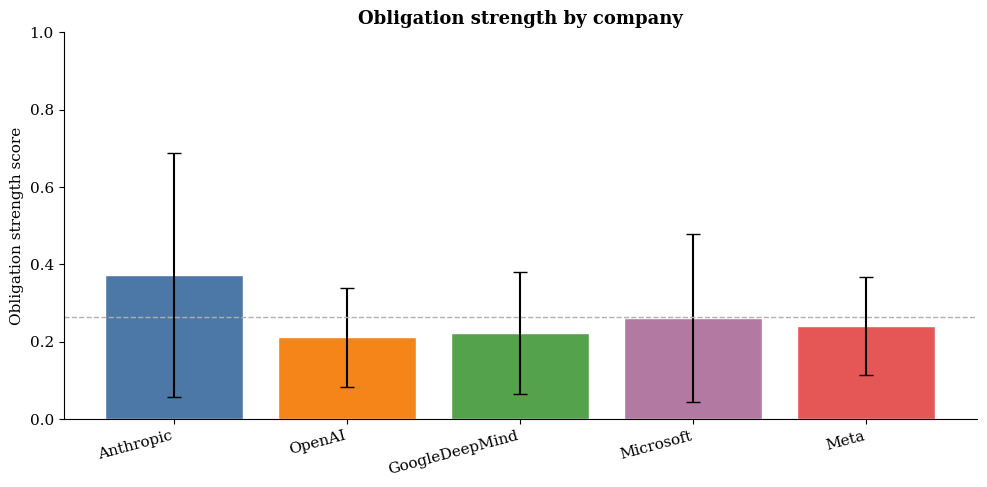

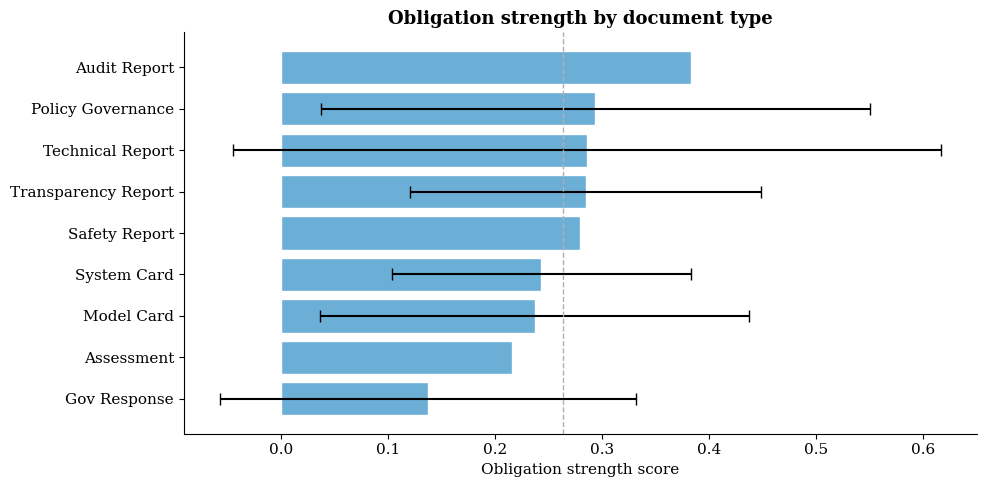

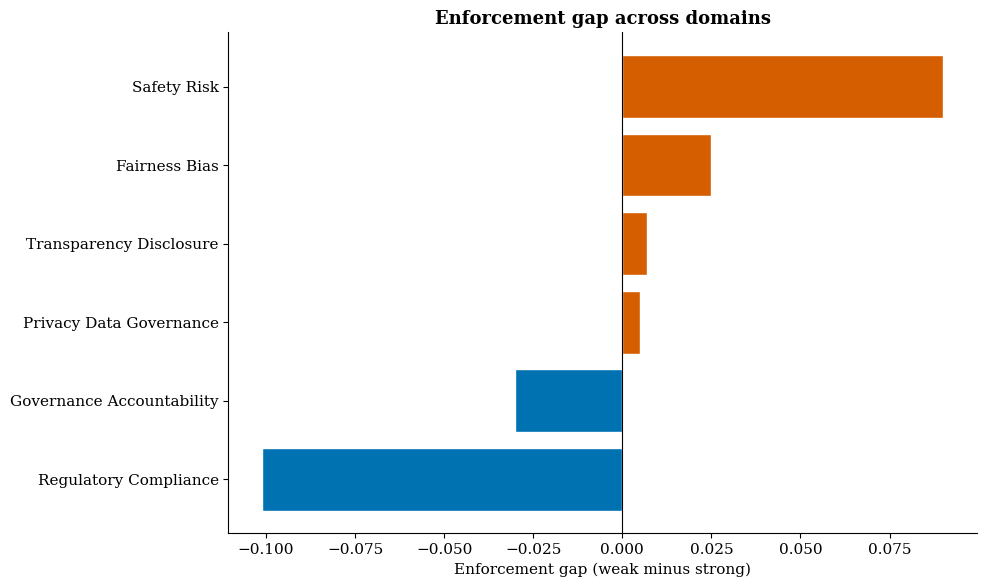

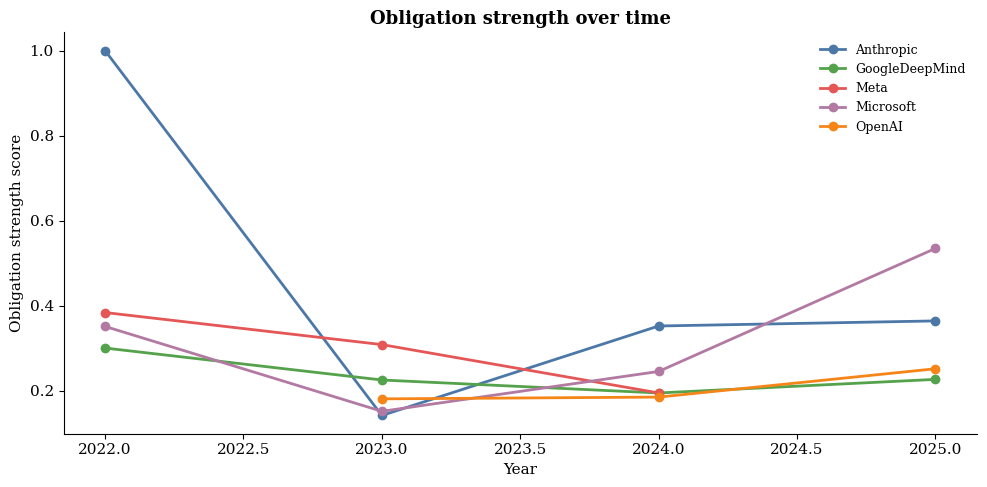

In [24]:
# Step 14: Figures for the paper

# Global style for all figures

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'legend.frameon': False
})

# Consistent color palette
COLORS = {
    'Anthropic': '#4C78A8',
    'OpenAI': '#F58518',
    'GoogleDeepMind': '#54A24B',
    'Microsoft': '#B279A2',
    'Meta': '#E45756'
}

NEUTRAL = '#4A4A4A'
LIGHT_GRAY = '#B0B0B0'


# Figure 1: Obligation strength by company
fig, ax = plt.subplots(figsize=(10, 5))

co_data = doc_level_df.groupby('company')['obligation_strength_score'].agg(['mean','std'])
co_data = co_data.reindex([c for c in COLORS.keys() if c in co_data.index])

colors = [COLORS[c] for c in co_data.index]

ax.bar(range(len(co_data)), co_data['mean'],
       yerr=co_data['std'],
       capsize=5,
       color=colors,
       edgecolor='white')

ax.set_xticks(range(len(co_data)))
ax.set_xticklabels(co_data.index, rotation=15, ha='right')

ax.set_ylabel("Obligation strength score")
ax.set_title("Obligation strength by company")

ax.set_ylim(0, 1)

# Reference line
ax.axhline(doc_level_df['obligation_strength_score'].mean(),
           color=LIGHT_GRAY, linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig1_obligation_by_company.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig1_obligation_by_company.pdf"))

plt.show()


# Figure 2: Obligation strength by document type
fig, ax = plt.subplots(figsize=(10, 5))

dt_data = doc_level_df.groupby('doc_type')['obligation_strength_score'].agg(['mean','std'])
dt_data = dt_data.sort_values('mean')

ax.barh(range(len(dt_data)), dt_data['mean'],
        xerr=dt_data['std'],
        capsize=4,
        color='#6BAED6',  # soft blue
        edgecolor='white')

ax.set_yticks(range(len(dt_data)))
ax.set_yticklabels([t.replace('_',' ').title() for t in dt_data.index])

ax.set_xlabel("Obligation strength score")
ax.set_title("Obligation strength by document type")

ax.axvline(doc_level_df['obligation_strength_score'].mean(),
           color=LIGHT_GRAY, linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig2_obligation_by_doctype.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig2_obligation_by_doctype.pdf"))

plt.show()


# Figure 3: Actor responsibility heatmap by company
#Commenting out because I do not need thid 
'''
fig, ax = plt.subplots(figsize=(10, 6))

actor_data = doc_level_df.groupby('company')[
    ['prop_actor_organization','prop_actor_developer',
     'prop_actor_user','prop_actor_ai_system']
].mean()

actor_data.columns = ['Organization','Developer','User','AI System']

sns.heatmap(
s   actor_data,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label':'Proportion'},
    ax=ax
)

ax.set_title("Actor responsibility distribution by company")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig3_actor_heatmap.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig3_actor_heatmap.pdf"))

plt.show()

'''

# Figure 4: Enforcement gap — what stays aspirational?
fig, ax = plt.subplots(figsize=(10, 6))

ep = gap_df.sort_values('gap')

colors = ['#D55E00' if g > 0 else '#0072B2' for g in ep['gap']]

ax.barh(range(len(ep)), ep['gap'],
        color=colors,
        edgecolor='white')

ax.set_yticks(range(len(ep)))
ax.set_yticklabels([d.replace('_',' ').title() for d in ep['domain']])

ax.set_xlabel("Enforcement gap (weak minus strong)")
ax.set_title("Enforcement gap across domains")

ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig4_enforcement_gap.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig4_enforcement_gap.pdf"))

plt.show()


# Figure 5: Obligation strength over time by company
fig, ax = plt.subplots(figsize=(10, 5))

time_data = doc_level_df.groupby(['year','company'])['obligation_strength_score'].mean().reset_index()

for company in time_data['company'].unique():
    ct = time_data[time_data['company'] == company]

    if len(ct) > 1:
        ax.plot(
            ct['year'],
            ct['obligation_strength_score'],
            marker='o',
            label=company,
            linewidth=2,
            color=COLORS.get(company, NEUTRAL)
        )

ax.set_xlabel("Year")
ax.set_ylabel("Obligation strength score")
ax.set_title("Obligation strength over time")

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig5_obligation_over_time.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig5_obligation_over_time.pdf"))

plt.show()

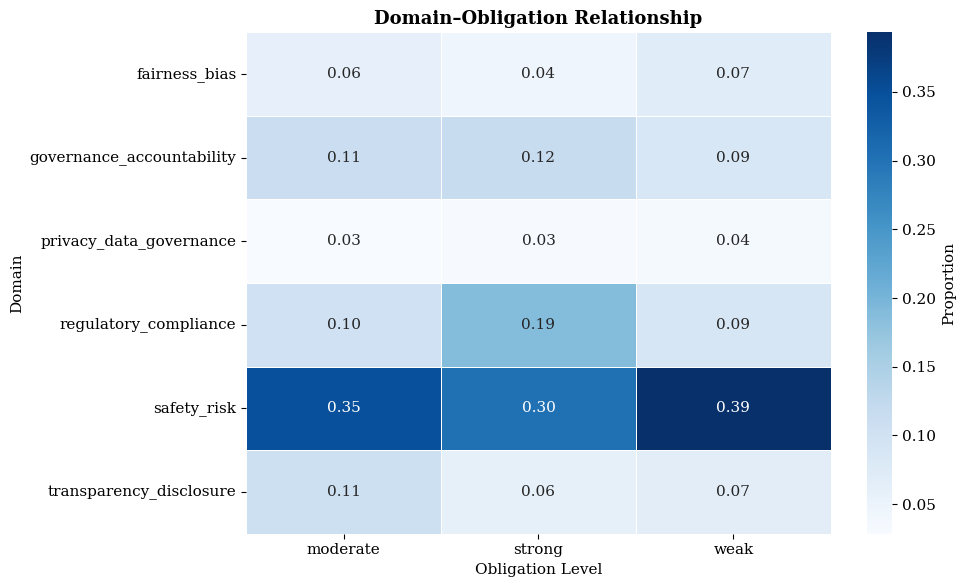

In [25]:
#Domain-Obligation Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

heat_data = domain_obligation_df.pivot(
    index='domain',
    columns='obligation_level',
    values='rate'
)

sns.heatmap(
    heat_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={'label': 'Proportion'},
    ax=ax
)

ax.set_title("Domain–Obligation Relationship")
ax.set_xlabel("Obligation Level")
ax.set_ylabel("Domain")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig_domain_obligation_heatmap.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig_domain_obligation_heatmap.pdf"))

plt.show()

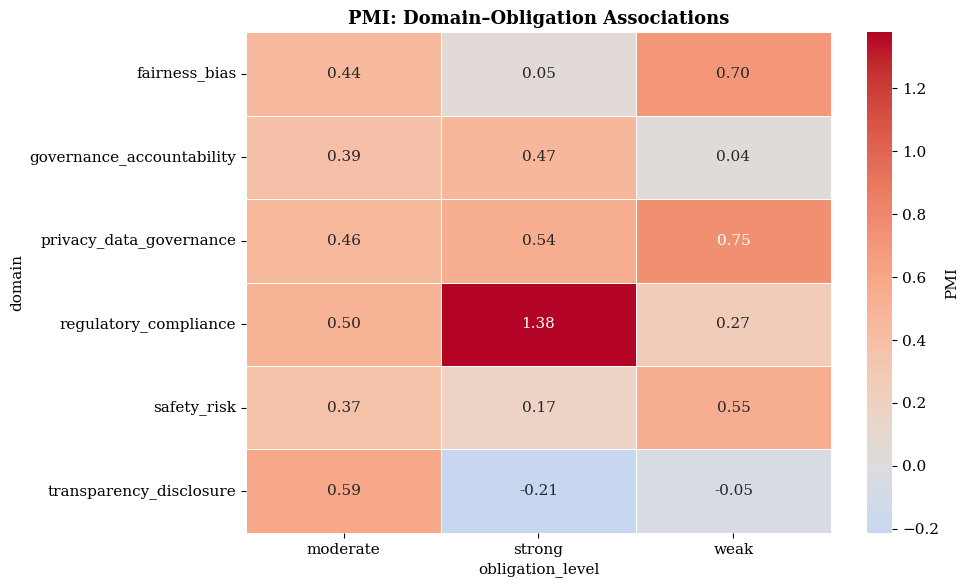

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

pmi_heat = pmi_df.pivot(
    index='domain',
    columns='obligation_level',
    values='pmi'
)

sns.heatmap(
    pmi_heat,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'PMI'},
    ax=ax
)

ax.set_title("PMI: Domain–Obligation Associations")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig_pmi_heatmap.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_FOLDER, "fig_pmi_heatmap.pdf"))
plt.show()

In [27]:
print("Outputs saved to /kaggle/working/")

print("\nKey files:")
print("- sentences_analyzed.csv")
print("- document_level_stats.csv")
print("- enforcement_gap.csv")
print("- pmi_analysis.csv")
print("- rq4_regression.txt")

print("\nFigures:")
print("- fig1 to fig5")

print("\nNext step: Run R notebook for STM (topic modeling)")

Outputs saved to /kaggle/working/

Key files:
- sentences_analyzed.csv
- document_level_stats.csv
- enforcement_gap.csv
- pmi_analysis.csv
- rq4_regression.txt

Figures:
- fig1 to fig5

Next step: Run R notebook for STM (topic modeling)


In [28]:
print(reg_df.columns.tolist())

['doc_id', 'n_sentences', 'doc_length_log', 'prop_strong_obligation', 'prop_moderate_obligation', 'prop_weak_obligation', 'prop_none_obligation', 'obligation_strength_score', 'n_obligation_sentences', 'prop_domain_safety_risk', 'prop_domain_fairness_bias', 'prop_domain_transparency_disclosure', 'prop_domain_privacy_data_governance', 'prop_domain_governance_accountability', 'prop_domain_regulatory_compliance', 'year', 'filename', 'word_count', 'word_count_std', 'company_GoogleDeepMind', 'company_Meta', 'company_Microsoft', 'company_OpenAI', 'doc_type_audit_report', 'doc_type_gov_response', 'doc_type_model_card', 'doc_type_policy_governance', 'doc_type_safety_report', 'doc_type_system_card', 'doc_type_technical_report', 'doc_type_transparency_report', 'safety_x_systemcard']
